In [ ]:
#######################################################################################
# CHANGELOG
#
# Changed np.random.choice to np.random.randint which is faster.
#
#
#
#
#
#######################################################################################


import numpy as np
import matplotlib.pyplot as plt

# Initial conditions
radius = 21                                               # starting radius
length = 51                                               # starting length

heat = np.zeros((length, length))                         # tracks age of particles
space = np.zeros((length, length), dtype=bool)            # boolean array to represent discrete 2D space: True for occupied block, false for empty block
space[length//2, length//2] = True                        # puts the seed in the middle


stickiness = 1                                            # factor value between (0 to 1). The chance it has of sticking to the seed
seed = True


# Functions
def spawn(radius):
    theta = np.random.uniform(0, 2 * np.pi)                                        # generates a random angle between 0 and 2pi
    x, y = int(radius * np.cos(theta)), int(radius * np.sin(theta))
    return x, y


def random_walk(n, length, space, heat, radius, s, r_max):
    
    L = length
    S = space
    H = heat

    center = L // 2
    x, y = spawn(radius)                                                                 # spawns particle at random point on circle
    x += center                                                                          # aligns circle to be centered at the seed
    y += center                                                                          # aligns circle to be centered at the seed  


    while (True):                                                                        # Loop until the particle sticks to seed
        # RANDOM WALK ALGORITHM
        direction = np.random.randint(4)
        if direction == 0:
            y = (y + 1) % L
        elif direction == 1:
            y = (y - 1) % L
        elif direction == 2:
            x = (x - 1) % L
        else:
            x = (x + 1) % L
        
        if (S[x-1:x+2, y-1:y+2].any()):                                                # Check if particle is next to the seed (3x3 neighborhood)
            if np.random.rand() < s:                                                   # Chance of sticking to the seed is the stickiness factor
                S[x, y] = True                                                         # places particle on crystal if it sticks
                H[x, y] = n + 1                                                        # tracks the age of the particle that sticks to the seed

                r_n = int(np.sqrt((x - center)**2 + (y - center)**2)) + 1              # distance from the center seed
                if n == 0:
                    r_max = 1
                elif r_n > r_max:
                    r_max = r_n
                break                                                                  # moved break inside the if so it only breaks if the particle sticks


    if L < (2 * r_max) + 20:
        new_length = L + 10
        if new_length % 2 == 0:
            new_length += 1

        new_space = np.zeros((new_length, new_length), dtype=bool)
        new_heat = np.zeros((new_length, new_length))

        shift = (new_length - L) // 2
        new_space[shift:shift+L, shift:shift+L] = S                                     # puts the old space in the middle of the new space
        new_heat[shift:shift+L, shift:shift+L] = H                                      # puts the old heat in the middle of the new heat                      

        length = new_length
        space = new_space
        heat = new_heat
    else:
        length = L
        space = S
        heat = H

    if radius < r_max + 10:
        radius = r_max + 10

    return length, space, heat, radius, r_max



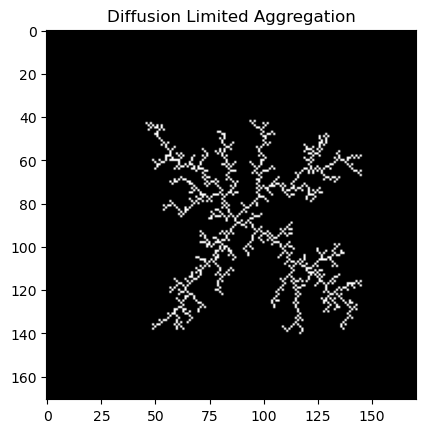

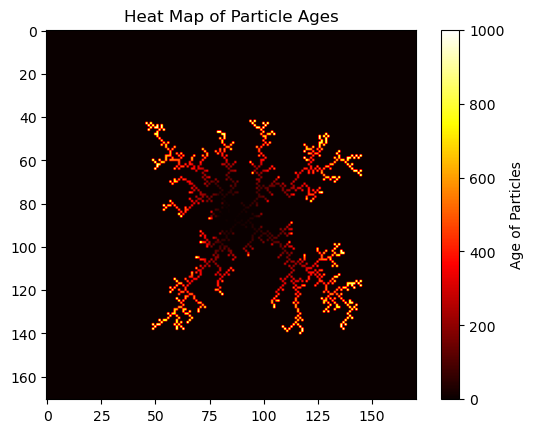

In [37]:
# Initial conditions
radius = 21                                               # starting radius
length = 51                                               # starting length
r_max = 1                                                 # starting longest branch length

heat = np.zeros((length, length))                         # tracks age of particles
space = np.zeros((length, length), dtype=bool)            # boolean array to represent discrete 2D space: True for occupied block, false for empty block
space[length//2, length//2] = True                        # puts the seed in the middle



stickiness = 1                                            # factor value between (0 to 1). The chance it has of sticking to the seed


# DLA Simulation

x, y = spawn(radius)

N = 1000 # number of particles
for n in range(N):
    length, space, heat, radius, r_max = random_walk(n, length, space, heat, radius, stickiness, r_max)

# image plotting from matplotlib plots the space array
plt.imshow(space, cmap='gray')
plt.title('Diffusion Limited Aggregation')
plt.show()

# plot heat map
plt.imshow(heat, cmap='hot')
plt.title('Heat Map of Particle Ages')
plt.colorbar(label='Age of Particles')
plt.show()